# KAIST sequence observability over time

This notebook loads one KAIST Urban sequence selected by number, builds consecutive 5-second windows, computes one calibration observability result per window, and plots:

1. principal CRLB-like values \(1 / \sigma_i^2\);
2. observability condition number.

The nominal trajectory used only as the **linearization point** is obtained from one explicitly selected LiDAR scan-to-map trajectory:

\[
T_{WB}(t) = T_{WL}(t)\,T_{BL}^{-1}.
\]

The scan-to-map trajectory is not treated as ground truth.

The notebook keeps the KAIST loading/window construction pattern used by the existing training and augmentation notebooks. The scientific observability calculation itself is isolated in one function so it can be changed later without touching dataset loading or plotting.


In [15]:
from pathlib import Path
from dataclasses import dataclass
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm


##################################################
# Repository discovery
##################################################

ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate the nn-obs-calib repository root containing src/obscalib."
    )

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


##################################################
# KAIST and nn-obs-calib imports
##################################################

from kaist_dataset import load_imus
from kaist_dataset.lidar import load_lidar_map_poses as load_lidar_map_pose_csv

from obscalib.config import WindowingConfig
from obscalib.data.adapter import (
    PreprocessedCalibration,
    PreprocessedSensorStream,
    build_window_samples_from_preprocessed,
)
from obscalib.data.structures import GeometryType, MeasurementType, WindowSample
from obscalib.observability.layout import CalibrationParameterLayout
from obscalib.observability.linearization import linearize_single_window
from obscalib.observability.matrix import compute_observability_matrix_single_window
from obscalib.observability.metrics import (
    compute_condition_number,
    compute_crlb,
    compute_numerical_rank,
    compute_singular_values,
)
from obscalib.observability.numerics import (
    ObservabilityNumericsConfig,
    singular_value_tolerance,
)
from obscalib.observability.timebase import ReferenceTimebase


DTYPE = torch.float64

print("Repository root:", ROOT)

Repository root: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib


## Configuration

`SEQUENCE_NUMBER` is the main dataset selector. The default reference is the left VLP-16 because the nominal `T_B_L` below is the established left-LiDAR KAIST calibration used in the existing notebooks.

The default residual covariances are identity matrices so the notebook can be used immediately as a **relative observability diagnostic**. For physically interpretable CRLB magnitudes, replace them with the empirical covariances produced by the KAIST measurement-noise estimation workflow.


In [16]:
##################################################
# Sequence and paths
##################################################

SEQUENCE_NUMBER = 16
SEQUENCE_NAME = f"Urban{SEQUENCE_NUMBER:02d}"
SEQUENCE_SLUG = SEQUENCE_NAME.lower()

KAIST_DATASET_ROOT = Path("/mnt/d/Downloads/MobRobLab/KAISTDataset")
LIDAR_POSE_ROOT = Path("/home/camel/Skoltech/phd_proposal/data/KAISTDataset")

DATASET_ROOT = KAIST_DATASET_ROOT / SEQUENCE_NAME
SENSOR_DATA_ROOT = (
    DATASET_ROOT
    / f"{SEQUENCE_SLUG}_data"
    / SEQUENCE_SLUG
    / "sensor_data"
)

LIDAR_SIDES = (
    "left",
    "right",
)

LIDAR_MAP_POSE_CSV_BY_SIDE = {
    side: (
        LIDAR_POSE_ROOT
        / SEQUENCE_NAME
        / f"lidar_map_poses_vlp_{side}.csv"
    )
    for side in LIDAR_SIDES
}

# One LiDAR still defines the trajectory/reference grid.
# Both LiDARs contribute independent factors/calibration blocks.
REFERENCE_LIDAR_SIDE = "left"
REFERENCE_LIDAR_STREAM_KEY = "lidar_left"


##################################################
# Windowing
##################################################

WINDOW_DURATION_S = 5.0
WINDOW_STRIDE_S = 5.0

MAX_SAMPLES_PER_SENSOR = 700

LOAD_IMU_FREQUENCY_HZ = None
MAX_IMU_FILES = None


##################################################
# Analysis controls
##################################################

MAX_WINDOWS = None
SKIP_FAILED_WINDOWS = True

PARAMETER_SCALES = None

RELATIVE_NUMERICAL_TOLERANCE = 1e-10

# If a physical coordinate contains a numerically meaningful component in
# Fisher nullspace, its coordinate-wise CRLB is reported as infinity.
COORDINATE_NULLSPACE_TOLERANCE = 1e-8

OUTPUT_ROOT = (
    ROOT
    / "outputs"
    / "kaist_observability"
    / SEQUENCE_NAME
)

SAVE_RESULTS = True
SAVE_DPI = 200


##################################################
# KAIST body-frame calibration
##################################################

# Left VLP-16 -> body.
T_B_LL = np.array(
    [
        [-0.514066, -0.702201, -0.492595, -0.440699],
        [ 0.486485, -0.711672,  0.506809,  0.397052],
        [-0.706447,  0.0208933,  0.707457,  1.90953],
        [ 0.0,       0.0,       0.0,       1.0],
    ],
    dtype=float,
)

# Right VLP-16 -> body.
T_B_RL = np.array(
    [
        [-0.512152,  0.699241, -0.498761, -0.449885],
        [-0.494811, -0.714859, -0.494104, -0.416713],
        [-0.702041, -0.0062642, 0.712109, 1.91294],
        [ 0.0,       0.0,        0.0,      1.0],
    ],
    dtype=float,
)

T_B_LIDAR_BY_SIDE = {
    "left": T_B_LL,
    "right": T_B_RL,
}

T_I_B = np.array(
    [
        [1.0, 0.0, 0.0, -0.07],
        [0.0, 1.0, 0.0,  0.0],
        [0.0, 0.0, 1.0,  1.7],
        [0.0, 0.0, 0.0,  1.0],
    ],
    dtype=float,
)

T_B_I = np.linalg.inv(T_I_B)

TAU_IMU_S = 0.0
TAU_LIDAR_LEFT_S = 0.0
TAU_LIDAR_RIGHT_S = 0.0

GRAVITY_WORLD = torch.tensor(
    [0.0, 0.0, 9.81],
    dtype=DTYPE,
)


##################################################
# Empirical KAIST measurement noise
##################################################

GYRO_MEASUREMENT_COVARIANCE = torch.tensor(
    [
        [ 2.96367932e-06, -1.94438078e-07, -4.83643437e-07],
        [-1.94438078e-07,  1.89162212e-06,  1.09062693e-07],
        [-4.83643437e-07,  1.09062693e-07,  1.88843506e-06],
    ],
    dtype=DTYPE,
)

ACCEL_MEASUREMENT_COVARIANCE = torch.tensor(
    [
        [ 4.85003041e-03, -9.25262862e-05,  2.14219676e-04],
        [-9.25262862e-05,  1.51980006e-03, -1.13182999e-03],
        [ 2.14219676e-04, -1.13182999e-03,  2.29777687e-03],
    ],
    dtype=DTYPE,
)

LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE = torch.tensor(
    [
        [1.10442767e-05, 9.46809587e-07, 3.78536515e-06],
        [9.46809587e-07, 3.35041997e-05, 1.90008728e-06],
        [3.78536515e-06, 1.90008728e-06, 1.10553483e-05],
    ],
    dtype=DTYPE,
)

LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE = torch.tensor(
    [
        [0.00843466, 0.00266052, 0.00702046],
        [0.00266052, 0.01444850, 0.00225705],
        [0.00702046, 0.00225705, 0.00704268],
    ],
    dtype=DTYPE,
)

# The empirical LiDAR covariance above belongs to one absolute scan-to-map
# pose T_W_L. Our factor measurement is
#
#     Z_01 = inv(T_W_L0) @ T_W_L1.
#
# Ignoring scan-to-scan correlation and higher-order adjoint effects, the
# first-order covariance of the relative measurement is approximately the
# sum of the two endpoint covariances: 2 * Sigma_scan_to_map.
LIDAR_SCAN_TO_MAP_COVARIANCE = torch.zeros(
    (6, 6),
    dtype=DTYPE,
)

LIDAR_SCAN_TO_MAP_COVARIANCE[:3, :3] = (
    LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE
)
LIDAR_SCAN_TO_MAP_COVARIANCE[3:, 3:] = (
    LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE
)

LIDAR_RELATIVE_RESIDUAL_COVARIANCE = (
    2.0
    * LIDAR_SCAN_TO_MAP_COVARIANCE
)


print("Sequence:", SEQUENCE_NAME)
print("Sensor data root:", SENSOR_DATA_ROOT)

for side in LIDAR_SIDES:
    print(
        f"{side} LiDAR map-pose CSV:",
        LIDAR_MAP_POSE_CSV_BY_SIDE[side],
    )

print(
    "Reference LiDAR:",
    REFERENCE_LIDAR_SIDE,
)
print(
    "Window:",
    WINDOW_DURATION_S,
    "s, stride:",
    WINDOW_STRIDE_S,
    "s",
)

Sequence: Urban16
Sensor data root: /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_data/urban16/sensor_data
left LiDAR map-pose CSV: /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv
right LiDAR map-pose CSV: /home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_map_poses_vlp_right.csv
Reference LiDAR: left
Window: 5.0 s, stride: 5.0 s


## Loading and trajectory helpers

Only successful finite scan-to-map LiDAR poses are retained. Consecutive accepted poses are converted into relative LiDAR measurements, so the relative measurements and the nominal linearization trajectory are guaranteed to use the same scan sequence.

Per-window body poses are translated to a local origin while retaining their world orientation. This avoids large georeferenced translations entering SE(3) adjoints without changing gravity orientation or relative motion.


In [17]:
def load_successful_lidar_map_poses(
    csv_path: Path,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load successful finite scan-to-map LiDAR poses T_W_L.

    Returns:
        timestamps_s:
            Successful scan timestamps, shape [N].
        poses_T_W_L:
            Successful absolute LiDAR poses, shape [N, 4, 4].
        source_indices:
            Original CSV row indices of the successful scans.
    """

    (
        timestamps_s,
        poses_T_W_L,
        dataframe,
    ) = load_lidar_map_pose_csv(
        csv_path
    )

    timestamps_s = np.asarray(
        timestamps_s,
        dtype=float,
    ).reshape(-1)

    poses_T_W_L = np.asarray(
        poses_T_W_L,
        dtype=float,
    )

    if "success" in dataframe.columns:
        success_mask = dataframe[
            "success"
        ].to_numpy(
            dtype=bool,
        )
    else:
        success_mask = np.ones(
            len(dataframe),
            dtype=bool,
        )

    finite_mask = np.all(
        np.isfinite(
            poses_T_W_L[:, :3, :]
        ),
        axis=(1, 2),
    )

    mask = (
        success_mask
        & finite_mask
    )

    source_indices = np.flatnonzero(
        mask
    )

    timestamps_s = timestamps_s[
        mask
    ]
    poses_T_W_L = poses_T_W_L[
        mask
    ]

    if len(timestamps_s) < 2:
        raise ValueError(
            "Need at least two successful finite LiDAR "
            f"map poses: {csv_path}"
        )

    if np.any(
        np.diff(
            timestamps_s
        )
        <= 0.0
    ):
        raise ValueError(
            "Successful LiDAR map-pose timestamps "
            "must be strictly increasing."
        )

    return (
        timestamps_s,
        poses_T_W_L,
        source_indices,
    )


def build_relative_lidar_intervals(
    timestamps_s: np.ndarray,
    poses_T_W_L: np.ndarray,
    source_indices: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Construct relative LiDAR poses only between adjacent original scans.

    This prevents two successful poses separated by one or more failed
    scan-to-map registrations from becoming one artificial long interval.
    """

    timestamps_s = np.asarray(
        timestamps_s,
        dtype=float,
    )
    poses_T_W_L = np.asarray(
        poses_T_W_L,
        dtype=float,
    )
    source_indices = np.asarray(
        source_indices,
        dtype=int,
    )

    if (
        len(timestamps_s)
        != len(poses_T_W_L)
        or len(timestamps_s)
        != len(source_indices)
    ):
        raise ValueError(
            "LiDAR timestamps, poses, and source indices "
            "must have equal lengths."
        )

    adjacent_mask = (
        np.diff(
            source_indices
        )
        == 1
    )

    start_poses = poses_T_W_L[
        :-1
    ][adjacent_mask]
    end_poses = poses_T_W_L[
        1:
    ][adjacent_mask]

    interval_start_timestamps_s = (
        timestamps_s[:-1][
            adjacent_mask
        ]
    )
    interval_end_timestamps_s = (
        timestamps_s[1:][
            adjacent_mask
        ]
    )

    relative_poses = (
        np.linalg.inv(
            start_poses
        )
        @ end_poses
    )

    return (
        relative_poses,
        interval_start_timestamps_s,
        interval_end_timestamps_s,
    )


def nearest_pose_indices(
    source_timestamps_s: np.ndarray,
    query_timestamps_s: np.ndarray,
    *,
    tolerance_s: float = 5e-5,
) -> np.ndarray:
    """
    Match query timestamps to nearest available scan-to-map poses.
    """

    source_timestamps_s = np.asarray(
        source_timestamps_s,
        dtype=float,
    )
    query_timestamps_s = np.asarray(
        query_timestamps_s,
        dtype=float,
    )

    right_indices = np.searchsorted(
        source_timestamps_s,
        query_timestamps_s,
        side="left",
    )

    right_indices = np.clip(
        right_indices,
        0,
        len(source_timestamps_s) - 1,
    )

    left_indices = np.clip(
        right_indices - 1,
        0,
        len(source_timestamps_s) - 1,
    )

    right_errors = np.abs(
        source_timestamps_s[
            right_indices
        ]
        - query_timestamps_s
    )

    left_errors = np.abs(
        source_timestamps_s[
            left_indices
        ]
        - query_timestamps_s
    )

    indices = np.where(
        right_errors < left_errors,
        right_indices,
        left_indices,
    )

    errors = np.abs(
        source_timestamps_s[
            indices
        ]
        - query_timestamps_s
    )

    if np.any(
        errors
        > tolerance_s
    ):
        worst_index = int(
            np.argmax(
                errors
            )
        )

        raise ValueError(
            "Could not match reference LiDAR timestamp "
            f"{query_timestamps_s[worst_index]:.9f}; "
            f"nearest error is "
            f"{errors[worst_index]:.6g} s."
        )

    return indices


def point_stream_has_window_data(
    timestamps_s: np.ndarray,
    window_start_time_s: float,
    window_end_time_s: float,
) -> bool:
    """
    Reproduce the half-open point-stream rule [start, end).
    """

    start_index = np.searchsorted(
        timestamps_s,
        window_start_time_s,
        side="left",
    )

    end_index = np.searchsorted(
        timestamps_s,
        window_end_time_s,
        side="left",
    )

    return (
        start_index
        < end_index
    )


def interval_stream_has_window_data(
    interval_start_timestamps_s: np.ndarray,
    interval_end_timestamps_s: np.ndarray,
    window_start_time_s: float,
    window_end_time_s: float,
) -> bool:
    """
    Reproduce the complete-interval rule used by build_windows().
    """

    mask = (
        (
            interval_start_timestamps_s
            >= window_start_time_s
        )
        & (
            interval_end_timestamps_s
            <= window_end_time_s
        )
    )

    return bool(
        np.any(
            mask
        )
    )


def build_retained_window_start_times(
    common_start_time_s: float,
    common_end_time_s: float,
    *,
    window_duration_s: float,
    window_stride_s: float,
    point_timestamp_groups: tuple[np.ndarray, ...],
    interval_timestamp_groups: tuple[
        tuple[np.ndarray, np.ndarray],
        ...,
    ],
) -> np.ndarray:
    """
    Reconstruct exact candidate starts retained by build_windows().

    This is required because build_windows() drops candidate windows with a
    missing stream. Therefore output-list index is not necessarily equal to
    candidate-window index.
    """

    available_duration_s = (
        common_end_time_s
        - common_start_time_s
    )

    if (
        available_duration_s
        < window_duration_s
    ):
        return np.empty(
            0,
            dtype=float,
        )

    num_candidate_windows = (
        int(
            np.floor(
                (
                    available_duration_s
                    - window_duration_s
                )
                / window_stride_s
                + 1e-12
            )
        )
        + 1
    )

    retained_start_times = []

    for candidate_index in range(
        num_candidate_windows
    ):
        window_start_time_s = (
            common_start_time_s
            + candidate_index
            * window_stride_s
        )

        window_end_time_s = (
            window_start_time_s
            + window_duration_s
        )

        point_streams_available = all(
            point_stream_has_window_data(
                timestamps_s,
                window_start_time_s,
                window_end_time_s,
            )
            for timestamps_s
            in point_timestamp_groups
        )

        interval_streams_available = all(
            interval_stream_has_window_data(
                interval_start_timestamps_s,
                interval_end_timestamps_s,
                window_start_time_s,
                window_end_time_s,
            )
            for (
                interval_start_timestamps_s,
                interval_end_timestamps_s,
            )
            in interval_timestamp_groups
        )

        if (
            point_streams_available
            and interval_streams_available
        ):
            retained_start_times.append(
                window_start_time_s
            )

    return np.asarray(
        retained_start_times,
        dtype=float,
    )


def reference_body_trajectory_for_window(
    window: WindowSample,
    window_start_time_s: float,
    lidar_map_timestamps_s: np.ndarray,
    lidar_map_poses_T_W_L: np.ndarray,
    T_B_L: np.ndarray,
) -> tuple[
    ReferenceTimebase,
    torch.Tensor,
]:
    """
    Construct T_W_B on the selected reference-LiDAR timestamps.
    """

    lidar_stream = window.streams[
        REFERENCE_LIDAR_STREAM_KEY
    ]

    if (
        lidar_stream.interval_start_timestamps
        is None
    ):
        raise ValueError(
            "Reference LiDAR stream must carry "
            "interval_start_timestamps."
        )

    reference_timestamps = torch.unique(
        torch.cat(
            (
                lidar_stream.interval_start_timestamps,
                lidar_stream.timestamps,
            )
        ),
        sorted=True,
    ).to(
        device="cpu",
        dtype=DTYPE,
    )

    reference_timebase = ReferenceTimebase(
        stream_key=REFERENCE_LIDAR_STREAM_KEY,
        timestamps=reference_timestamps,
    )

    reference_timebase.validate()

    absolute_reference_timestamps_s = (
        window_start_time_s
        + reference_timestamps.detach().cpu().numpy()
    )

    pose_indices = nearest_pose_indices(
        lidar_map_timestamps_s,
        absolute_reference_timestamps_s,
    )

    T_W_L = np.asarray(
        lidar_map_poses_T_W_L[
            pose_indices
        ],
        dtype=float,
    )

    T_L_B = np.linalg.inv(
        T_B_L
    )

    T_W_B = (
        T_W_L
        @ T_L_B
    )

    # Keep the world orientation, but remove the large map translation.
    T_W_B_local = (
        T_W_B.copy()
    )

    world_origin = (
        T_W_B_local[
            0,
            :3,
            3,
        ].copy()
    )

    T_W_B_local[
        :,
        :3,
        3,
    ] -= world_origin

    trajectory_poses = torch.as_tensor(
        T_W_B_local,
        dtype=DTYPE,
        device="cpu",
    )

    return (
        reference_timebase,
        trajectory_poses,
    )

## Load one KAIST sequence

This follows the same Xsens loading pattern used by the existing KAIST notebooks. The LiDAR branch loads scan-to-map poses directly because those poses also provide the nominal trajectory for the observability linearization.


In [ ]:
##################################################
# IMU
##################################################

imu_streams = load_imus(
    SENSOR_DATA_ROOT,
    target_frequency_hz=LOAD_IMU_FREQUENCY_HZ,
    max_files=MAX_IMU_FILES,
)

if not imu_streams:
    raise ValueError(
        f"No KAIST IMU streams were found below {SENSOR_DATA_ROOT}."
    )

primary_imu_name = list(
    imu_streams.keys()
)[0]

primary_imu = imu_streams[
    primary_imu_name
]


##################################################
# Left and right scan-to-map LiDAR trajectories
##################################################

lidar_map_timestamps_s_by_side = {}
lidar_map_poses_T_W_L_by_side = {}
lidar_source_indices_by_side = {}

lidar_relative_poses_by_side = {}
lidar_interval_start_timestamps_s_by_side = {}
lidar_interval_end_timestamps_s_by_side = {}

for side in LIDAR_SIDES:
    (
        lidar_map_timestamps_s,
        lidar_map_poses_T_W_L,
        lidar_source_indices,
    ) = load_successful_lidar_map_poses(
        LIDAR_MAP_POSE_CSV_BY_SIDE[
            side
        ]
    )

    (
        lidar_relative_poses,
        lidar_interval_start_timestamps_s,
        lidar_interval_end_timestamps_s,
    ) = build_relative_lidar_intervals(
        lidar_map_timestamps_s,
        lidar_map_poses_T_W_L,
        lidar_source_indices,
    )

    lidar_map_timestamps_s_by_side[
        side
    ] = lidar_map_timestamps_s

    lidar_map_poses_T_W_L_by_side[
        side
    ] = lidar_map_poses_T_W_L

    lidar_source_indices_by_side[
        side
    ] = lidar_source_indices

    lidar_relative_poses_by_side[
        side
    ] = lidar_relative_poses

    lidar_interval_start_timestamps_s_by_side[
        side
    ] = lidar_interval_start_timestamps_s

    lidar_interval_end_timestamps_s_by_side[
        side
    ] = lidar_interval_end_timestamps_s


##################################################
# Basic diagnostics
##################################################

imu_dt = np.diff(
    primary_imu.timestamps_s
)

print(
    "Primary IMU:",
    primary_imu_name,
)
print(
    "IMU samples:",
    len(
        primary_imu.timestamps_s
    ),
)
print(
    "IMU median frequency [Hz]:",
    1.0
    / np.median(
        imu_dt
    ),
)
print()

for side in LIDAR_SIDES:
    timestamps_s = (
        lidar_map_timestamps_s_by_side[
            side
        ]
    )

    interval_starts = (
        lidar_interval_start_timestamps_s_by_side[
            side
        ]
    )

    interval_ends = (
        lidar_interval_end_timestamps_s_by_side[
            side
        ]
    )

    print(
        f"{side} LiDAR successful scans:",
        len(
            timestamps_s
        ),
    )
    print(
        f"{side} LiDAR adjacent relative intervals:",
        len(
            interval_starts
        ),
    )

    if len(
        timestamps_s
    ) > 1:
        print(
            f"{side} LiDAR median scan frequency [Hz]:",
            1.0
            / np.median(
                np.diff(
                    timestamps_s
                )
            ),
        )

    print(
        f"{side} LiDAR support:",
        timestamps_s[0],
        "...",
        timestamps_s[-1],
    )
    print()

print(
    "IMU support:",
    primary_imu.timestamps_s[0],
    "...",
    primary_imu.timestamps_s[-1],
)

## Build 5-second windows

The window representation is the same `PreprocessedSensorStream -> WindowSample` path used by the existing augmentation/training notebooks.

The sequence is restricted to common IMU/LiDAR support. Windows are non-overlapping by default (`stride = 5 s`), but changing only `WINDOW_STRIDE_S` gives a rolling analysis, for example a 5-second window every 1 second.


In [ ]:
##################################################
# Preprocessed streams
##################################################

streams = {
    "gyro": PreprocessedSensorStream(
        values=primary_imu.gyro_radps,
        timestamps_s=primary_imu.timestamps_s,
        measurement_type=MeasurementType.IMU_GYROSCOPE,
        geometry_type=GeometryType.VECTOR,
        calibration_key="imu",
    ),

    "accel": PreprocessedSensorStream(
        values=primary_imu.accel_mps2,
        timestamps_s=primary_imu.timestamps_s,
        measurement_type=MeasurementType.IMU_ACCELEROMETER,
        geometry_type=GeometryType.VECTOR,
        calibration_key="imu",
    ),

    "lidar_left": PreprocessedSensorStream(
        values=lidar_relative_poses_by_side[
            "left"
        ],
        timestamps_s=lidar_interval_end_timestamps_s_by_side[
            "left"
        ],
        interval_start_timestamps_s=lidar_interval_start_timestamps_s_by_side[
            "left"
        ],
        measurement_type=MeasurementType.LIDAR_POSE,
        geometry_type=GeometryType.SE3,
        calibration_key="lidar_left",
    ),

    "lidar_right": PreprocessedSensorStream(
        values=lidar_relative_poses_by_side[
            "right"
        ],
        timestamps_s=lidar_interval_end_timestamps_s_by_side[
            "right"
        ],
        interval_start_timestamps_s=lidar_interval_start_timestamps_s_by_side[
            "right"
        ],
        measurement_type=MeasurementType.LIDAR_POSE,
        geometry_type=GeometryType.SE3,
        calibration_key="lidar_right",
    ),
}


##################################################
# Current calibration
##################################################

current_calibration = {
    "imu": PreprocessedCalibration(
        transform=T_B_I,
        time_offset_s=TAU_IMU_S,
    ),

    "lidar_left": PreprocessedCalibration(
        transform=T_B_LL,
        time_offset_s=TAU_LIDAR_LEFT_S,
    ),

    "lidar_right": PreprocessedCalibration(
        transform=T_B_RL,
        time_offset_s=TAU_LIDAR_RIGHT_S,
    ),
}


##################################################
# Common temporal support
##################################################

common_start_time_s = max(
    float(
        primary_imu.timestamps_s[
            0
        ]
    ),
    *[
        float(
            lidar_interval_start_timestamps_s_by_side[
                side
            ][0]
        )
        for side in LIDAR_SIDES
    ],
)

common_end_time_s = min(
    float(
        primary_imu.timestamps_s[
            -1
        ]
    ),
    *[
        float(
            lidar_interval_end_timestamps_s_by_side[
                side
            ][-1]
        )
        for side in LIDAR_SIDES
    ],
)


##################################################
# Window construction
##################################################

windowing_config = WindowingConfig(
    window_duration_s=WINDOW_DURATION_S,
    window_stride_s=WINDOW_STRIDE_S,
    max_samples_per_sensor=MAX_SAMPLES_PER_SENSOR,
)

window_samples = build_window_samples_from_preprocessed(
    streams,
    current_calibration,
    windowing_config=windowing_config,
    start_time=common_start_time_s,
    end_time=common_end_time_s,
    dtype=DTYPE,
    timestamp_dtype=torch.float64,
)


##################################################
# Recover the actual retained candidate start times
##################################################

window_start_times_s = (
    build_retained_window_start_times(
        common_start_time_s,
        common_end_time_s,
        window_duration_s=WINDOW_DURATION_S,
        window_stride_s=WINDOW_STRIDE_S,
        point_timestamp_groups=(
            np.asarray(
                primary_imu.timestamps_s,
                dtype=float,
            ),
        ),
        interval_timestamp_groups=tuple(
            (
                lidar_interval_start_timestamps_s_by_side[
                    side
                ],
                lidar_interval_end_timestamps_s_by_side[
                    side
                ],
            )
            for side in LIDAR_SIDES
        ),
    )
)

if (
    len(
        window_start_times_s
    )
    != len(
        window_samples
    )
):
    raise RuntimeError(
        "Independent reconstruction of retained window starts "
        "does not match build_window_samples_from_preprocessed(): "
        f"{len(window_start_times_s)} starts versus "
        f"{len(window_samples)} WindowSample objects."
    )


##################################################
# Diagnostics
##################################################

candidate_window_count = (
    int(
        np.floor(
            (
                common_end_time_s
                - common_start_time_s
                - WINDOW_DURATION_S
            )
            / WINDOW_STRIDE_S
            + 1e-12
        )
    )
    + 1
)

print(
    "Common support [s]:",
    common_start_time_s,
    "...",
    common_end_time_s,
)
print(
    "Candidate windows:",
    candidate_window_count,
)
print(
    "Retained windows:",
    len(
        window_samples
    ),
)
print(
    "Rejected windows:",
    candidate_window_count
    - len(
        window_samples
    ),
)

if window_samples:
    first_window = (
        window_samples[0]
    )

    print()

    for (
        stream_key,
        stream,
    ) in first_window.streams.items():
        print(
            stream_key,
            "samples =",
            len(
                stream.timestamps
            ),
            "value shape =",
            tuple(
                stream.values.shape
            ),
            "interval-valued =",
            stream.interval_start_timestamps
            is not None,
        )

Common support [s]: 1524205126.62 ... 1524209584.81
Number of analysis windows: 788
gyro samples = 500 value shape = (500, 3) interval-valued = False
accel samples = 500 value shape = (500, 3) interval-valued = False
lidar samples = 49 value shape = (49, 4, 4) interval-valued = True


## Observability configuration

The calibration matrix uses the deterministic block order `("imu", "lidar")`, hence 14 calibration dimensions.

The covariance matrices enter whitening. With identity covariance the resulting curves are useful for motion-dependent comparisons over time, but the absolute scale of the CRLB-like plot is not a physical uncertainty bound.


In [ ]:
CALIBRATION_KEYS = (
    "imu",
    "lidar_left",
    "lidar_right",
)

calibration_layout = (
    CalibrationParameterLayout.from_calibration_keys(
        CALIBRATION_KEYS
    )
)


##################################################
# Residual covariance
##################################################

residual_covariance_by_stream = {
    # NOTE:
    # This is the empirical per-sample angular-velocity covariance.
    # The current factor API accepts one constant stream covariance, so this
    # remains an approximation for the integrated gyroscope residual.
    # Ultimately this covariance should be propagated through the interval
    # integration inside the gyroscope factor itself.
    "gyro": GYRO_MEASUREMENT_COVARIANCE,

    "accel": ACCEL_MEASUREMENT_COVARIANCE,

    "lidar_left": LIDAR_RELATIVE_RESIDUAL_COVARIANCE,

    "lidar_right": LIDAR_RELATIVE_RESIDUAL_COVARIANCE,
}


##################################################
# Nuisance state
##################################################

gyro_bias_by_calibration_key = {
    "imu": torch.zeros(
        3,
        dtype=DTYPE,
    ),
}


##################################################
# Numerical policy
##################################################

numerics = ObservabilityNumericsConfig(
    relative_tolerance=RELATIVE_NUMERICAL_TOLERANCE,
    parameter_scales=PARAMETER_SCALES,
)


##################################################
# API preflight
##################################################

linearization_parameters = inspect.signature(
    linearize_single_window
).parameters

required_linearization_parameters = {
    "trajectory_poses",
    "residual_covariance_by_stream",
}

missing_parameters = (
    required_linearization_parameters
    - set(
        linearization_parameters
    )
)

if missing_parameters:
    raise RuntimeError(
        "The local linearize_single_window() is older than "
        "this notebook's observability pipeline. "
        "Missing keyword parameters: "
        f"{sorted(missing_parameters)}."
    )

print(
    "Calibration keys:",
    calibration_layout.calibration_keys,
)
print(
    "Calibration dimension:",
    calibration_layout.total_dimension,
)
print(
    "linearize_single_window signature:"
)
print(
    inspect.signature(
        linearize_single_window
    )
)

Calibration dimension: 14
linearize_single_window signature:
(measurements: 'Mapping[str, SensorStream]', metadata: 'Mapping[str, SensorMetadata]', calibration: 'Mapping[str, CalibrationState]', calibration_layout: 'CalibrationParameterLayout', reference_timebase: 'ReferenceTimebase', *, trajectory_poses: 'torch.Tensor | None' = None, gyro_bias_by_calibration_key: 'Mapping[str, torch.Tensor] | None' = None, residual_covariance_by_stream: 'Mapping[str, torch.Tensor] | None' = None, gravity_world: 'torch.Tensor | None' = None, lidar_interval_start_timestamps_by_stream: 'Mapping[str, torch.Tensor] | None' = None) -> 'WindowLinearization'

Residual covariance mode: unit/debug


## One-window observability function

This is the only cell that knows the observability implementation API. Dataset loading, windowing, trajectory construction, storage, and plotting are independent from it.

For compatibility with the recently revised metric semantics, the function expects `compute_crlb()` to return the principal-axis vector \(1/\sigma_i^2\). A small fallback derives those values from the singular spectrum if an older matrix-valued CRLB implementation is still present.


In [ ]:
@dataclass
class WindowObservabilityRecord:
    """Observability quantities retained for one temporal window."""

    window_index: int
    window_start_time_s: float
    window_center_time_s: float

    singular_values: np.ndarray

    # Coordinate-wise sqrt(CRLB diagonal), ordered exactly like
    # CalibrationParameterLayout:
    #
    #   [phi_x, phi_y, phi_z, rho_x, rho_y, rho_z, tau]
    #
    # for every calibration key.
    coordinate_crlb_std: np.ndarray

    condition_number: float
    numerical_rank: int


def coordinate_crlb_standard_deviation(
    fisher_information_matrix: torch.Tensor,
    *,
    relative_tolerance: float,
    nullspace_tolerance: float,
) -> torch.Tensor:
    """
    Calculate coordinate-wise CRLB-like 1-sigma lower bounds.

    For a full-rank Fisher matrix this is

        sqrt(diag(inv(F))).

    For a rank-deficient Fisher matrix, a coordinate is reported as +inf if
    that coordinate axis contains a meaningful component in the numerical
    nullspace. This avoids the misleading zero variances produced by blindly
    reading diag(pinv(F)).
    """

    F = fisher_information_matrix.to(
        device="cpu",
        dtype=DTYPE,
    )

    F = 0.5 * (
        F
        + F.T
    )

    eigenvalues, eigenvectors = (
        torch.linalg.eigh(
            F
        )
    )

    maximum_eigenvalue = torch.max(
        torch.abs(
            eigenvalues
        )
    )

    tolerance = (
        float(
            relative_tolerance
        )
        * float(
            maximum_eigenvalue.item()
        )
    )

    materially_negative = (
        eigenvalues
        < -tolerance
    )

    if torch.any(
        materially_negative
    ):
        raise ValueError(
            "Fisher information matrix has materially "
            "negative eigenvalues."
        )

    # Roundoff-scale negative eigenvalues are clipped to zero.
    eigenvalues = torch.clamp(
        eigenvalues,
        min=0.0,
    )

    observable_mask = (
        eigenvalues
        > tolerance
    )

    null_mask = ~observable_mask

    number_parameters = (
        F.shape[0]
    )

    coordinate_variance = torch.zeros(
        number_parameters,
        dtype=DTYPE,
    )

    if torch.any(
        observable_mask
    ):
        observable_vectors = (
            eigenvectors[
                :,
                observable_mask,
            ]
        )

        observable_eigenvalues = (
            eigenvalues[
                observable_mask
            ]
        )

        coordinate_variance = torch.sum(
            observable_vectors.pow(
                2
            )
            / observable_eigenvalues.unsqueeze(
                0
            ),
            dim=1,
        )

    if torch.any(
        null_mask
    ):
        null_vectors = eigenvectors[
            :,
            null_mask,
        ]

        # Diagonal of the projector onto numerical nullspace.
        nullspace_coordinate_weight = torch.sum(
            null_vectors.pow(
                2
            ),
            dim=1,
        )

        unobservable_coordinates = (
            nullspace_coordinate_weight
            > nullspace_tolerance
        )
    else:
        unobservable_coordinates = torch.zeros(
            number_parameters,
            dtype=torch.bool,
        )

    coordinate_std = torch.sqrt(
        torch.clamp(
            coordinate_variance,
            min=0.0,
        )
    )

    coordinate_std[
        unobservable_coordinates
    ] = float(
        "inf"
    )

    return coordinate_std


def compute_window_observability(
    window: WindowSample,
    window_index: int,
    window_start_time_s: float,
) -> WindowObservabilityRecord:
    """
    Compute Fisher-derived observability for one KAIST window.
    """

    (
        reference_timebase,
        trajectory_poses,
    ) = reference_body_trajectory_for_window(
        window,
        window_start_time_s,
        lidar_map_timestamps_s_by_side[
            REFERENCE_LIDAR_SIDE
        ],
        lidar_map_poses_T_W_L_by_side[
            REFERENCE_LIDAR_SIDE
        ],
        T_B_LIDAR_BY_SIDE[
            REFERENCE_LIDAR_SIDE
        ],
    )

    linearization_kwargs = {
        "trajectory_poses": trajectory_poses,
        "gyro_bias_by_calibration_key": gyro_bias_by_calibration_key,
        "residual_covariance_by_stream": residual_covariance_by_stream,
    }

    if (
        "gravity_world"
        in linearization_parameters
    ):
        linearization_kwargs[
            "gravity_world"
        ] = GRAVITY_WORLD

    linearization = linearize_single_window(
        window.streams,
        window.metadata,
        window.current_calibration,
        calibration_layout,
        reference_timebase,
        **linearization_kwargs,
    )

    matrix_result = (
        compute_observability_matrix_single_window(
            linearization,
            numerics,
        )
    )

    singular_values = compute_singular_values(
        matrix_result,
        numerics,
    )

    condition_number = compute_condition_number(
        matrix_result,
        numerics,
    )

    numerical_rank = compute_numerical_rank(
        matrix_result,
        numerics,
    )

    coordinate_crlb_std = (
        coordinate_crlb_standard_deviation(
            matrix_result.fisher_information_matrix,
            relative_tolerance=RELATIVE_NUMERICAL_TOLERANCE,
            nullspace_tolerance=COORDINATE_NULLSPACE_TOLERANCE,
        )
    )

    return WindowObservabilityRecord(
        window_index=window_index,

        window_start_time_s=window_start_time_s,

        window_center_time_s=(
            window_start_time_s
            + 0.5
            * WINDOW_DURATION_S
        ),

        singular_values=(
            singular_values
            .detach()
            .cpu()
            .numpy()
        ),

        coordinate_crlb_std=(
            coordinate_crlb_std
            .detach()
            .cpu()
            .numpy()
        ),

        condition_number=float(
            condition_number
            .detach()
            .cpu()
            .item()
        ),

        numerical_rank=int(
            numerical_rank
        ),
    )

## Run the whole sequence

Failed windows can be skipped so isolated scan-to-map gaps do not erase the rest of the time series. The failure list is retained and printed afterward.


In [ ]:
num_windows_to_run = (
    len(
        window_samples
    )
    if MAX_WINDOWS is None
    else min(
        int(
            MAX_WINDOWS
        ),
        len(
            window_samples
        ),
    )
)

records: list[
    WindowObservabilityRecord
] = []

failed_windows: list[
    tuple[
        int,
        float,
        str,
    ]
] = []

for window_index in tqdm(
    range(
        num_windows_to_run
    ),
    desc=f"{SEQUENCE_NAME} observability",
):
    window = window_samples[
        window_index
    ]

    # IMPORTANT:
    # this is the retained candidate start corresponding to this window,
    # not common_start + output_list_index * stride.
    window_start_time_s = float(
        window_start_times_s[
            window_index
        ]
    )

    try:
        record = compute_window_observability(
            window,
            window_index,
            window_start_time_s,
        )

    except Exception as error:
        if not SKIP_FAILED_WINDOWS:
            raise

        failed_windows.append(
            (
                window_index,
                window_start_time_s,
                str(
                    error
                ),
            )
        )
        continue

    records.append(
        record
    )

if not records:
    raise RuntimeError(
        "No observability windows were computed successfully."
    )


##################################################
# Convert results to arrays
##################################################

window_indices = np.asarray(
    [
        record.window_index
        for record in records
    ],
    dtype=int,
)

window_center_times_s = np.asarray(
    [
        record.window_center_time_s
        for record in records
    ],
    dtype=float,
)

elapsed_time_s = (
    window_center_times_s
    - common_start_time_s
)

elapsed_time_min = (
    elapsed_time_s
    / 60.0
)

singular_values_over_time = np.stack(
    [
        record.singular_values
        for record in records
    ],
    axis=0,
)

coordinate_crlb_std_over_time = np.stack(
    [
        record.coordinate_crlb_std
        for record in records
    ],
    axis=0,
)

condition_number_over_time = np.asarray(
    [
        record.condition_number
        for record in records
    ],
    dtype=float,
)

rank_over_time = np.asarray(
    [
        record.numerical_rank
        for record in records
    ],
    dtype=int,
)


##################################################
# Summary
##################################################

summary = pd.DataFrame(
    {
        "window_index": window_indices,
        "window_center_time_s": window_center_times_s,
        "elapsed_time_s": elapsed_time_s,
        "condition_number": condition_number_over_time,
        "numerical_rank": rank_over_time,
    }
)

print(
    f"Successful windows: "
    f"{len(records)} / "
    f"{num_windows_to_run}"
)

print(
    "Failed windows:",
    len(
        failed_windows
    ),
)

print()

display(
    summary.head()
)

if failed_windows:
    print()
    print(
        "First failed windows:"
    )

    for failure in failed_windows[
        :10
    ]:
        print(
            failure
        )

Urban16 observability:   0%|          | 0/788 [00:00<?, ?it/s]

Successful windows: 21 / 788
Failed windows: 767



,window_index,window_center_time_s,elapsed_time_s,condition_number,numerical_rank
0,0,1.524205e+09,2.5,inf,7
1,1,1.524205e+09,7.5,inf,8
2,2,1.524205e+09,12.5,inf,8
3,3,1.524205e+09,17.5,inf,8
4,4,1.524205e+09,22.5,inf,8



First failed windows:
(21, 1524205231.62, 'Could not match reference LiDAR timestamp 1524205236.569999933; nearest error is 8.99 s.')
(22, 1524205236.62, 'Could not match reference LiDAR timestamp 1524205241.609999895; nearest error is 14.03 s.')
(23, 1524205241.62, 'Could not match reference LiDAR timestamp 1524205246.549999952; nearest error is 18.97 s.')
(24, 1524205246.62, 'Could not match reference LiDAR timestamp 1524205251.599999905; nearest error is 24.02 s.')
(25, 1524205251.62, 'Could not match reference LiDAR timestamp 1524205256.539999962; nearest error is 28.96 s.')
(26, 1524205256.62, 'Could not match reference LiDAR timestamp 1524205260.470000029; nearest error is 32.89 s.')
(27, 1524205261.62, 'Could not match reference LiDAR timestamp 1524205261.680000067; nearest error is 31.76 s.')
(28, 1524205266.62, 'Could not match reference LiDAR timestamp 1524205266.619999886; nearest error is 26.82 s.')
(29, 1524205271.62, 'Could not match reference LiDAR timestamp 1524205271.

## Principal CRLB-like values over time

Each line is one principal calibration direction, ordered by the observability singular spectrum. These are **principal directions**, not individual `phi/rho/tau` coordinates.

Infinite values correspond to numerically unobservable directions and are omitted from the log-scale line itself.


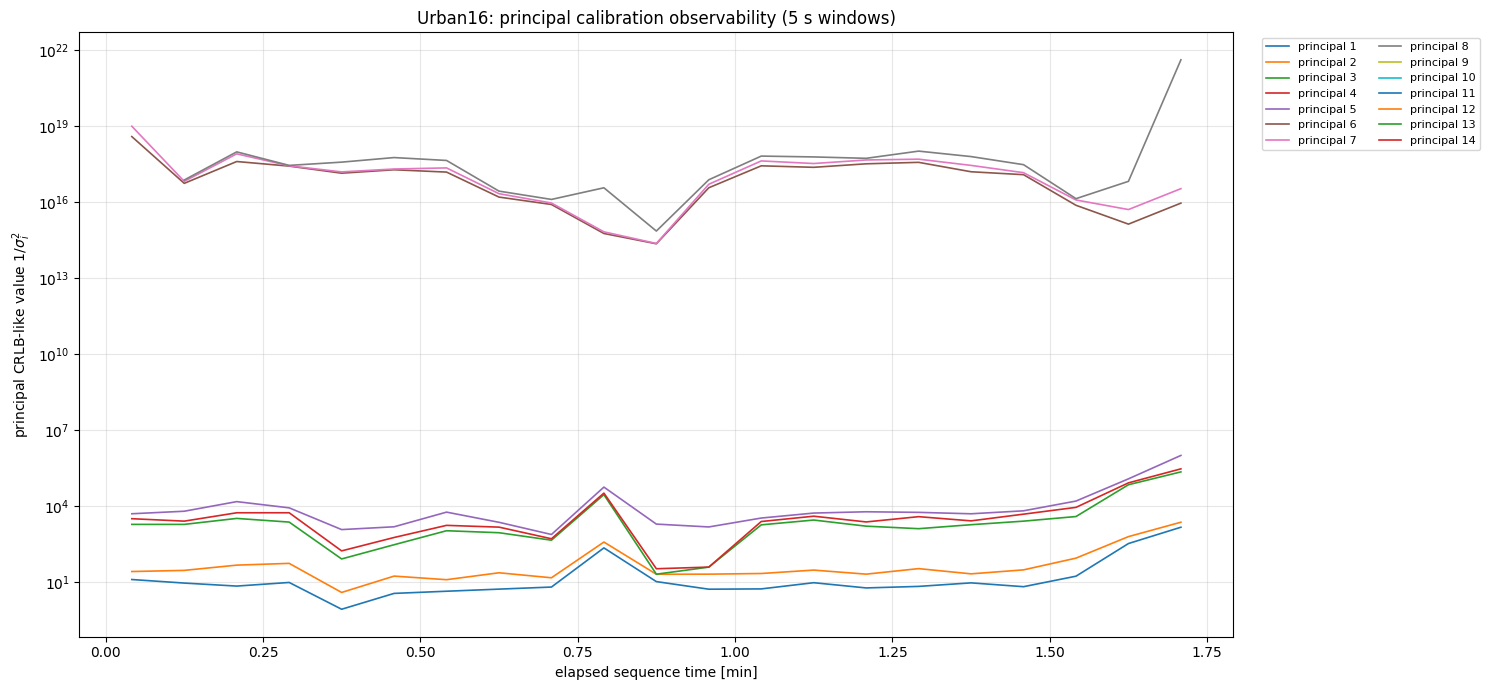

In [ ]:
CALIBRATION_DISPLAY_NAMES = {
    "imu": "IMU",
    "lidar_left": "Left LiDAR",
    "lidar_right": "Right LiDAR",
}

AXIS_NAMES = (
    "x",
    "y",
    "z",
)


def plot_crlb_coordinate_group(
    ax: plt.Axes,
    parameter_indices: list[int],
    component_names: tuple[str, ...],
    ylabel: str,
) -> None:
    """
    Plot coordinate-wise CRLB-like 1-sigma bounds on a logarithmic axis.
    """

    has_positive_value = False

    for (
        parameter_index,
        component_name,
    ) in zip(
        parameter_indices,
        component_names,
    ):
        values = (
            coordinate_crlb_std_over_time[
                :,
                parameter_index,
            ]
        )

        finite_positive = (
            np.isfinite(
                values
            )
            & (
                values
                > 0.0
            )
        )

        num_infinite = int(
            np.count_nonzero(
                ~np.isfinite(
                    values
                )
            )
        )

        label = (
            component_name
            if num_infinite == 0
            else (
                f"{component_name} "
                f"(∞: {num_infinite})"
            )
        )

        if np.any(
            finite_positive
        ):
            has_positive_value = True

            ax.plot(
                elapsed_time_min[
                    finite_positive
                ],
                values[
                    finite_positive
                ],
                linewidth=1.2,
                label=label,
            )

    if has_positive_value:
        ax.set_yscale(
            "log"
        )

    ax.set_ylabel(
        ylabel
    )
    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    handles, labels = (
        ax.get_legend_handles_labels()
    )

    if handles:
        ax.legend(
            fontsize=8,
        )


fig, axes = plt.subplots(
    3,
    len(
        CALIBRATION_KEYS
    ),
    figsize=(18, 11),
    sharex=True,
    squeeze=False,
)

for column_index, calibration_key in enumerate(
    CALIBRATION_KEYS
):
    block = calibration_layout.block_for(
        calibration_key
    )

    rotation_indices = [
        block.start + axis_index
        for axis_index in range(
            3
        )
    ]

    translation_indices = [
        block.start + 3 + axis_index
        for axis_index in range(
            3
        )
    ]

    time_offset_index = (
        block.start
        + 6
    )

    axes[
        0,
        column_index,
    ].set_title(
        CALIBRATION_DISPLAY_NAMES[
            calibration_key
        ]
    )

    plot_crlb_coordinate_group(
        axes[
            0,
            column_index,
        ],
        rotation_indices,
        AXIS_NAMES,
        r"rotation $1\sigma$ bound [rad]",
    )

    plot_crlb_coordinate_group(
        axes[
            1,
            column_index,
        ],
        translation_indices,
        AXIS_NAMES,
        r"translation $1\sigma$ bound [m]",
    )

    plot_crlb_coordinate_group(
        axes[
            2,
            column_index,
        ],
        [
            time_offset_index
        ],
        (
            r"$\tau$",
        ),
        r"time offset $1\sigma$ bound [s]",
    )

    axes[
        2,
        column_index,
    ].set_xlabel(
        "elapsed sequence time [min]"
    )

fig.suptitle(
    f"{SEQUENCE_NAME}: coordinate-wise calibration CRLB-like bounds "
    f"({WINDOW_DURATION_S:g} s windows)",
    y=1.01,
)

fig.tight_layout()

if SAVE_RESULTS:
    OUTPUT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        OUTPUT_ROOT
        / "coordinate_crlb_over_time.png",
        dpi=SAVE_DPI,
        bbox_inches="tight",
    )

plt.show()

## Condition number over time

Finite condition numbers are shown directly. Rank-deficient windows, for which the condition number is \(+\infty\), are marked with `x` symbols one decade above the largest finite value so they remain visible on the logarithmic plot.


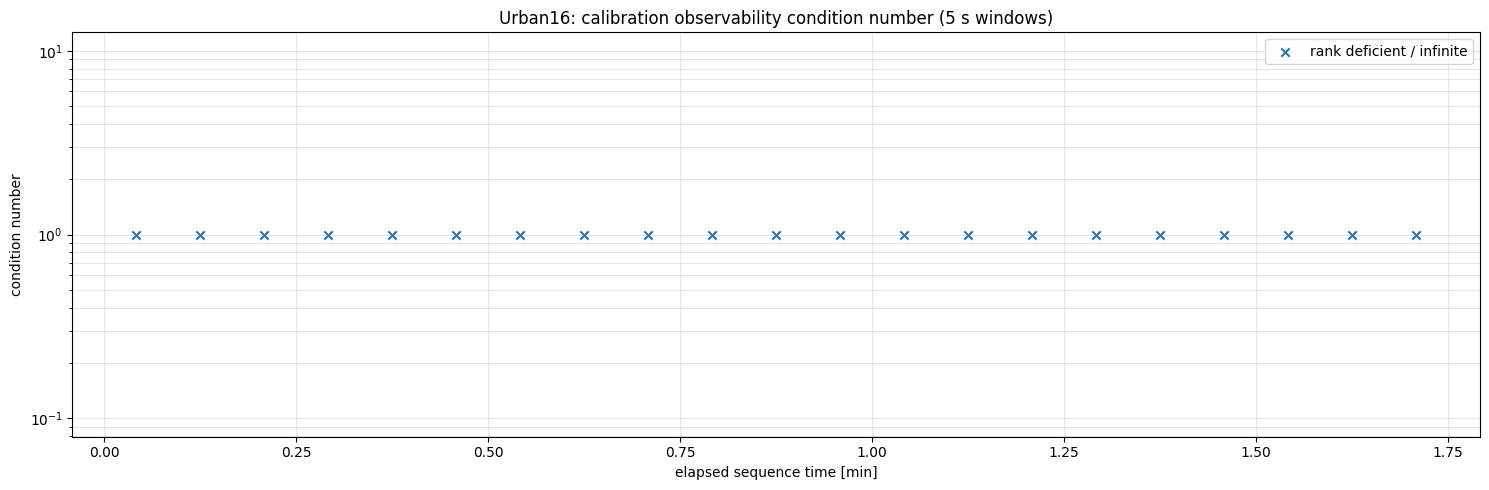

In [ ]:
fig, ax = plt.subplots(
    figsize=(15, 5),
)

finite_condition = (
    np.isfinite(condition_number_over_time)
    & (condition_number_over_time > 0.0)
)

if np.any(finite_condition):
    ax.plot(
        elapsed_time_min[finite_condition],
        condition_number_over_time[finite_condition],
        linewidth=1.4,
        label="finite condition number",
    )

    infinite_marker_level = (
        np.nanmax(
            condition_number_over_time[
                finite_condition
            ]
        )
        * 10.0
    )
else:
    infinite_marker_level = 1.0

infinite_condition = ~np.isfinite(
    condition_number_over_time
)

if np.any(infinite_condition):
    ax.scatter(
        elapsed_time_min[infinite_condition],
        np.full(
            int(np.count_nonzero(infinite_condition)),
            infinite_marker_level,
            dtype=float,
        ),
        marker="x",
        label="rank deficient / infinite",
    )

ax.set_yscale("log")
ax.set_xlabel("elapsed sequence time [min]")
ax.set_ylabel("condition number")
ax.set_title(
    f"{SEQUENCE_NAME}: calibration observability condition number "
    f"({WINDOW_DURATION_S:g} s windows)"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.tight_layout()

if SAVE_RESULTS:
    OUTPUT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )
    fig.savefig(
        OUTPUT_ROOT / "condition_number_over_time.png",
        dpi=SAVE_DPI,
        bbox_inches="tight",
    )

plt.show()

## Optional result export

The scalar table is saved as CSV. The full principal CRLB-like and singular-value arrays are saved separately because they have one column per calibration principal direction.


In [ ]:
if SAVE_RESULTS:
    OUTPUT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    summary.to_csv(
        OUTPUT_ROOT
        / "observability_summary.csv",
        index=False,
    )

    np.save(
        OUTPUT_ROOT
        / "coordinate_crlb_std_over_time.npy",
        coordinate_crlb_std_over_time,
    )

    np.save(
        OUTPUT_ROOT
        / "singular_values_over_time.npy",
        singular_values_over_time,
    )

    np.save(
        OUTPUT_ROOT
        / "condition_number_over_time.npy",
        condition_number_over_time,
    )

    np.save(
        OUTPUT_ROOT
        / "numerical_rank_over_time.npy",
        rank_over_time,
    )

    print(
        "Saved analysis to:",
        OUTPUT_ROOT,
    )

Saved analysis to: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/outputs/kaist_observability/Urban16
